# PINN Black-Scholes

In [41]:
# Standard library imports
import os
import time
from pathlib import Path

# Data manipulation and mathematics
import numpy as np
import pandas as pd
from scipy.stats import norm

# Visualization
import matplotlib.pyplot as plt
from matplotlib import cm

# Deep learning framework (PyTorch)
import torch
import torch.nn as nn
import torch.optim as optim

### Colab Setup

In [42]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    repo_url = "https://github.com/egil10/fys5429.git"
    repo_dir = "/content/fys5429"

    if not os.path.exists(repo_dir):
        !git clone {repo_url} {repo_dir}
    else:
        !git -C {repo_dir} pull

    os.chdir(os.path.join(repo_dir, "code", "notebooks"))

print(f"Working directory: {os.getcwd()}")

remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 5 (delta 3), reused 5 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (5/5), 482.17 KiB | 1.76 MiB/s, done.
From https://github.com/egil10/fys5429
   26c1708..be63e16  main       -> origin/main
Updating 26c1708..be63e16
Fast-forward
 code/notebooks/pinn_bs.ipynb | 153 +++++++++++++++++++++----------------------
 1 file changed, 74 insertions(+), 79 deletions(-)
Working directory: /content/fys5429/code/notebooks


### Paths

In [43]:
data_path = Path("..") / "data" / "generated" / "bs_collocation.parquet"

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    out_dir = Path("/content/drive/MyDrive/GITHUB-COLAB/fys5429/code/plots/eda")
else:
    out_dir = Path("..") / "plots" / "eda"

out_dir.mkdir(parents=True, exist_ok=True)
print(f"Plots will be saved to: {out_dir}")

out_path_pinn = out_dir / "pinn_bs.pdf"
out_path_loss_total = out_dir / "pinn_bs_loss_total.pdf"
out_path_loss_pde = out_dir / "pinn_bs_loss_pde.pdf"
out_path_loss_ic = out_dir / "pinn_bs_loss_ic.pdf"
out_path_loss_bc = out_dir / "pinn_bs_loss_bc.pdf"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Plots will be saved to: /content/drive/MyDrive/GITHUB-COLAB/fys5429/code/plots/eda


### Global parameters

In [44]:
# Answer to the universe and everything
torch.manual_seed(42)

# Use GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Adding torch backends
torch.backends.cudnn.benchmark = True

# Option Physics (Analytical Benchmarks)
K = 100.0
r = 0.05
sigma = 0.20
T_max = 1.0
S_max = 300.0

# NN (best from hyperparameter sweeps)
HIDDEN_LAYERS = 2
NEURONS_PER_LAYER = 256
LEARNING_RATE = 5e-4
EPOCHS = 50000
PRINT_ROWS = 20

# PINN Loss Weights (best from sweep 3: lambda)
LAMBDA_PDE = 10.0
LAMBDA_IC = 5.0
LAMBDA_BC = 5.0

Using device: cuda


In [45]:
import sys
sys.path.insert(0, "../scripts")
from bspinn import BSPINN
from train_bs import train_pinn

### Reading data

In [46]:
# Loading Parquet data file into a Pandas DataFrame
df_all = pd.read_parquet(data_path)

# Helper function to extract columns and turn them into gradient-tracking Tensors
def extract_tensors(df_subset):
    S_tensor = torch.tensor(df_subset['S'].values, dtype=torch.float32).view(-1, 1).to(device).requires_grad_(True)
    tau_tensor = torch.tensor(df_subset['tau'].values, dtype=torch.float32).view(-1, 1).to(device).requires_grad_(True)
    return S_tensor, tau_tensor

# Interior points
df_interior = df_all[df_all['point_type'] == 'interior']
S_in, tau_in = extract_tensors(df_interior)

# Initial Condition points (Maturity)
df_ic = df_all[df_all['point_type'] == 'initial_condition']
S_ic, tau_ic = extract_tensors(df_ic)

# Boundary Condition points (S = 0)
df_bc = df_all[df_all['point_type'] == 'boundary_condition']
S_bc, tau_bc = extract_tensors(df_bc)

print(f"Read data from {data_path}")
print(f"Interior points: {len(S_in)}")
print(f"IC points: {len(S_ic)}")
print(f"BC points: {len(S_bc)}")

Read data from ../data/generated/bs_collocation.parquet
Interior points: 5000
IC points: 1000
BC points: 250


### Training a PINN

In [47]:
model = BSPINN(hidden_layers=HIDDEN_LAYERS, neurons_per_layer=NEURONS_PER_LAYER, activation='tanh').to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

### Training Loop

In [48]:
# Inputs
epochs = EPOCHS
print(f"Starting PINN learning at {epochs} epochs")

Starting PINN learning at 50000 epochs


In [49]:
# Initialize history lists
history = {
    'epoch': [],
    'total': [],
    'pde': [],
    'ic': [],
    'bc': []
}

# Print the table header
print(f"{'Epoch':>6} | {'Total Loss':>12} | {'PDE Loss':>12} | {'IC Loss':>12} | {'BC Loss':>12}")
print("-" * 66)

# Creating an array **once** before the loop starts
# to stop memory thrashing
grad_ones = torch.ones_like(S_in)

# Start that timer!
start_time = time.time()

# Looping over the epochs
for epoch in range(epochs):

    # Always zero the gradient before a new step
    optimizer.zero_grad()

    # Calculating the PDE loss
    V_pred = model(S_in, tau_in)

    # Automatic differentiation for the gradients using the pre-allocated array!
    V_S = torch.autograd.grad(V_pred, S_in, grad_outputs=grad_ones, create_graph=True)[0]
    V_tau = torch.autograd.grad(V_pred, tau_in, grad_outputs=grad_ones, create_graph=True)[0]
    V_SS = torch.autograd.grad(V_S, S_in, grad_outputs=grad_ones, create_graph=True)[0]

    # Black-Scholes PDE equation
    pde_residual = V_tau - (0.5 * sigma**2 * S_in**2 * V_SS + r * S_in * V_S - r * V_pred)
    loss_pde = torch.mean(pde_residual**2)

    # Calculating the initial condition loss
    # which is the payoff at maturity
    V_ic_pred = model(S_ic, tau_ic)

    # True payoff of a Call option is maX(S-K, 0)
    V_ic_true = torch.relu(S_ic - K)
    loss_ic = torch.mean((V_ic_pred - V_ic_true)**2)

    # Calculating the boundary condition loss at S=0
    V_bc_pred = model(S_bc, tau_bc)

    # A call option is worth 0 if the stock price is 0
    loss_bc = torch.mean((V_bc_pred - 0.0)**2)

    # Total Loss and Backpropagation
    loss = (LAMBDA_PDE * loss_pde) + (LAMBDA_IC * loss_ic) + (LAMBDA_BC * loss_bc)

    # Compute the gradients and update the neural 
    # network weights
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # NEW
    optimizer.step()
    scheduler.step()  # NEW
    
    # Record history for plotting
    history['epoch'].append(epoch)
    history['total'].append(loss.item())
    history['pde'].append(loss_pde.item())
    history['ic'].append(loss_ic.item())
    history['bc'].append(loss_bc.item())

    # Print 20 rows of progress
    print_interval = max(1, epochs // PRINT_ROWS)
    if epoch % print_interval == 0:
        print(f"{epoch:6d} | {loss.item():12.6f} | {loss_pde.item():12.6f} | {loss_ic.item():12.6f} | {loss_bc.item():12.6f}")

# Stop that timer!
end_time = time.time()

# Calculate minutes and seconds
total_seconds = end_time - start_time
minutes = int(total_seconds // 60)
seconds = int(total_seconds % 60)

# Calculate dataset metrics
n_interior = len(S_in)
n_ic = len(S_ic)
n_bc = len(S_bc)
total_points = n_interior + n_ic + n_bc

# Printout training complete with the final metrics
print("-" * 66)
print(f"Training Complete! Trained {epochs} epochs in {minutes} minutes and {seconds} seconds.")
print(f"Dataset Size: {total_points:,} total points ({n_interior:,} Interior, {n_ic:,} IC, {n_bc:,} BC)")
print(f"Final Total Loss: {loss.item():.6f}")
print("=" * 66)


 Epoch |   Total Loss |     PDE Loss |      IC Loss |      BC Loss
------------------------------------------------------------------
     0 | 21994.251953 |     0.040190 |  4398.757324 |     0.012685
  2500 |     4.310508 |     0.073130 |     0.708925 |     0.006917
  5000 |     1.170991 |     0.045051 |     0.140892 |     0.003204
  7500 |     0.838488 |     0.040670 |     0.084463 |     0.001894
 10000 |     0.779964 |     0.042375 |     0.070118 |     0.001125
 12500 |     0.632704 |     0.033942 |     0.057838 |     0.000820
 15000 |     0.449724 |     0.021570 |     0.045805 |     0.001000
 17500 |     0.449238 |     0.022963 |     0.043321 |     0.000601
 20000 |     0.410178 |     0.021411 |     0.038676 |     0.000537
 22500 |     0.317941 |     0.014268 |     0.034567 |     0.000486
 25000 |     0.262849 |     0.010700 |     0.030556 |     0.000613
 27500 |     0.218712 |     0.008049 |     0.027121 |     0.000522
 30000 |     0.195775 |     0.007024 |     0.024696 |     0.00

### Pre-plotting

In [50]:
# Running another notebook including the analytical Black-Scholes
%run bs.ipynb

In [51]:
# Creating a clean 50x50 grid for plotting
S_plot = np.linspace(1e-5, S_max, 50)
tau_plot = np.linspace(0.01, T_max, 50)
S_grid, tau_grid = np.meshgrid(S_plot, tau_plot)

# Flatten the grids and convert to PyTorch
# tensors from the model
S_flat = torch.tensor(S_grid.flatten(), dtype=torch.float32).view(-1, 1).to(device)
tau_flat = torch.tensor(tau_grid.flatten(), dtype=torch.float32).view(-1, 1).to(device)

# Getting PINN predictions
# using torch.no_grad() because we are done training
# and dont need to track derivatives anymore
with torch.no_grad():
    V_pred_flat = model(S_flat, tau_flat).cpu().numpy()

# Reshape the flat predictions back into the 50x50
pinn_surface = V_pred_flat.reshape(S_grid.shape)

# Calculating true analyical prices
# assuming the bs function from earlier still
# in memory, passing tau_grid as T 
analytical_surface = bs(S=S_grid, K=K, T=tau_grid, r=r, sigma=sigma, type="call")

### Plotting the 3d surfaces

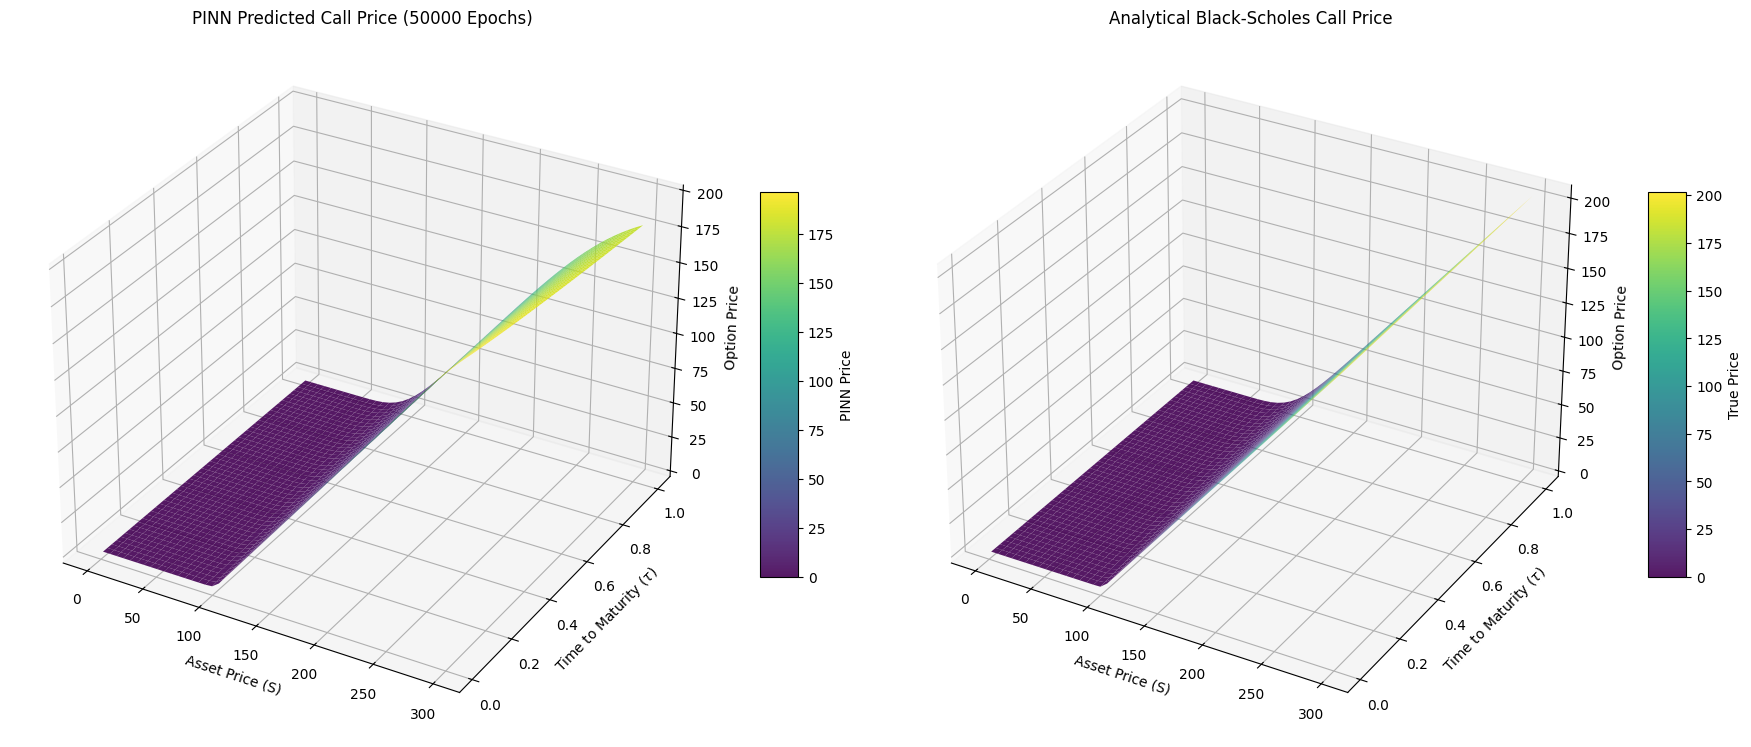

In [52]:
# Setting up the figure
fig = plt.figure(figsize=(18, 8))

# Left plot: PINN prediction
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(S_grid, tau_grid, pinn_surface, cmap=cm.viridis, edgecolor='none', alpha=0.9)
ax1.set_title(f'PINN Predicted Call Price ({epochs} Epochs)')
ax1.set_xlabel('Asset Price (S)')
ax1.set_ylabel('Time to Maturity ($\\tau$)')
ax1.set_zlabel('Option Price')
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10, label='PINN Price')

# Right plot: True math
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(S_grid, tau_grid, analytical_surface, cmap=cm.viridis, edgecolor='none', alpha=0.9)
ax2.set_title('Analytical Black-Scholes Call Price')
ax2.set_xlabel('Asset Price (S)')
ax2.set_ylabel('Time to Maturity ($\\tau$)')
ax2.set_zlabel('Option Price')
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10, label='True Price')

# Tight layout
plt.tight_layout()

# # Saving and showing the figure
plt.savefig(out_path_pinn, bbox_inches="tight")
plt.show()

### Plotting Total Loss

<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_5569/1014306016.py:5: SyntaxWarning: invalid escape sequence '\m'
  plt.title('Total Composite Loss $\mathcal{L}(\\theta)$')


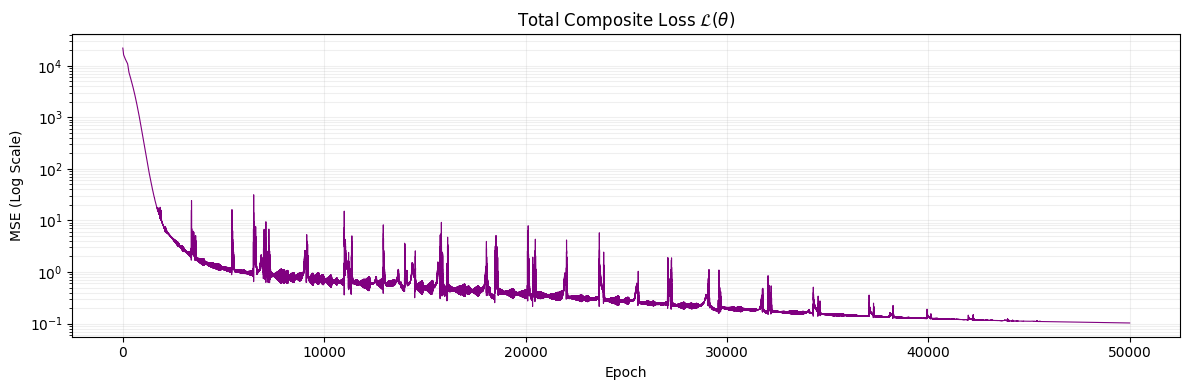

In [53]:
# Setting up figure 
plt.figure(figsize=(12, 4))
plt.plot(history['epoch'], history['total'], color='purple', lw=0.8)
plt.yscale('log')
plt.title('Total Composite Loss $\mathcal{L}(\\theta)$')
plt.xlabel('Epoch')
plt.ylabel('MSE (Log Scale)')
plt.grid(True, which="both", ls="-", alpha=0.2)

# Tight layout
plt.tight_layout()

# # Saving and showing the figure
plt.savefig(out_path_loss_total, bbox_inches="tight")
plt.show()

### Plotting PDE Loss

<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_5569/297257238.py:7: SyntaxWarning: invalid escape sequence '\m'
  plt.title('PDE Residual Loss ($\mathcal{L}_{pde}$)')


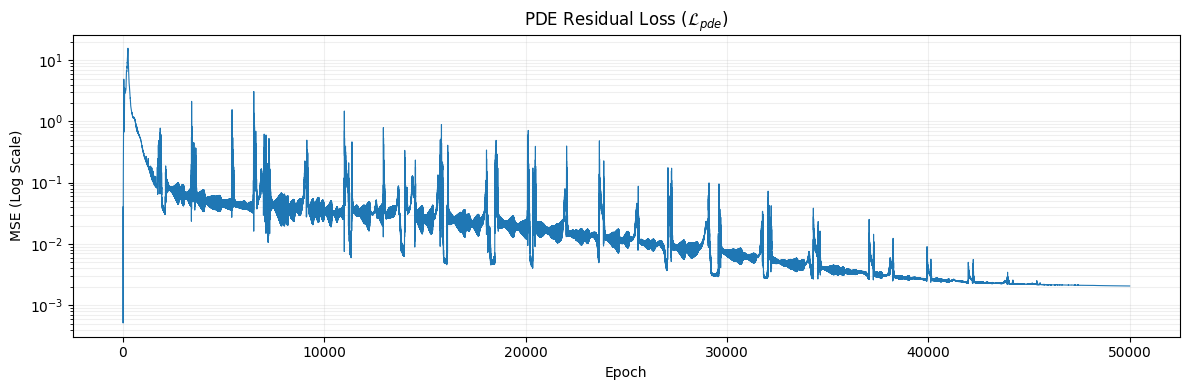

In [54]:
# Setting up the figure
plt.figure(figsize=(12, 4))
plt.plot(history['epoch'], history['pde'], color='tab:blue', lw=0.8)
plt.yscale('log')

# Title, axes titles, and grid
plt.title('PDE Residual Loss ($\mathcal{L}_{pde}$)')
plt.xlabel('Epoch')
plt.ylabel('MSE (Log Scale)')
plt.grid(True, which="both", ls="-", alpha=0.2)

# Tight layout
plt.tight_layout()

# # Saving and showing the figure
plt.savefig(out_path_loss_pde, bbox_inches="tight")
plt.show()

### Plotting Initial Condition Loss

<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_5569/4261623641.py:7: SyntaxWarning: invalid escape sequence '\m'
  plt.title('Initial Condition Loss ($\mathcal{L}_{ic}$)')


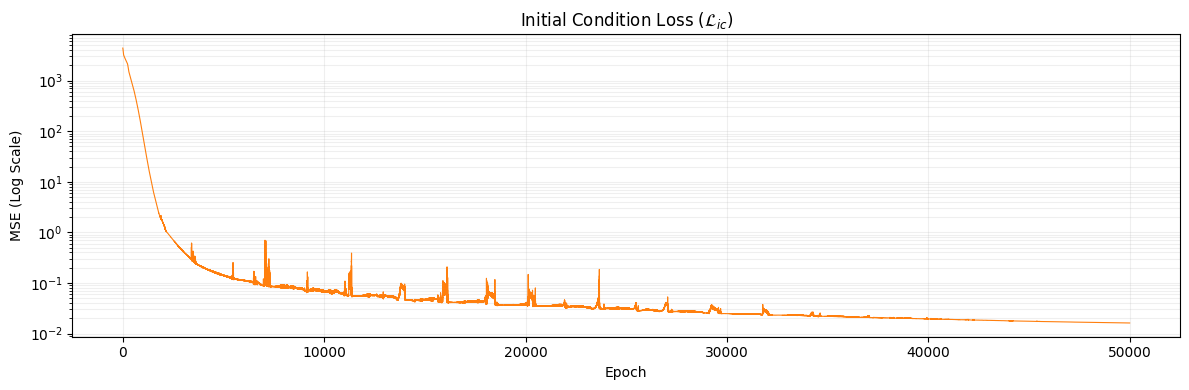

In [55]:
# Setting up the figure
plt.figure(figsize=(12, 4))
plt.plot(history['epoch'], history['ic'], color='tab:orange', lw=0.8)
plt.yscale('log')

# Title, axes titles, and grid
plt.title('Initial Condition Loss ($\mathcal{L}_{ic}$)')
plt.xlabel('Epoch')
plt.ylabel('MSE (Log Scale)')
plt.grid(True, which="both", ls="-", alpha=0.2)

# Tight layout
plt.tight_layout()

# # Saving and showing the figure
plt.savefig(out_path_loss_ic, bbox_inches="tight")
plt.show()

### Plotting Boundary Condition Loss

<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_5569/1750888344.py:7: SyntaxWarning: invalid escape sequence '\m'
  plt.title('Boundary Condition Loss ($\mathcal{L}_{bc}$)')


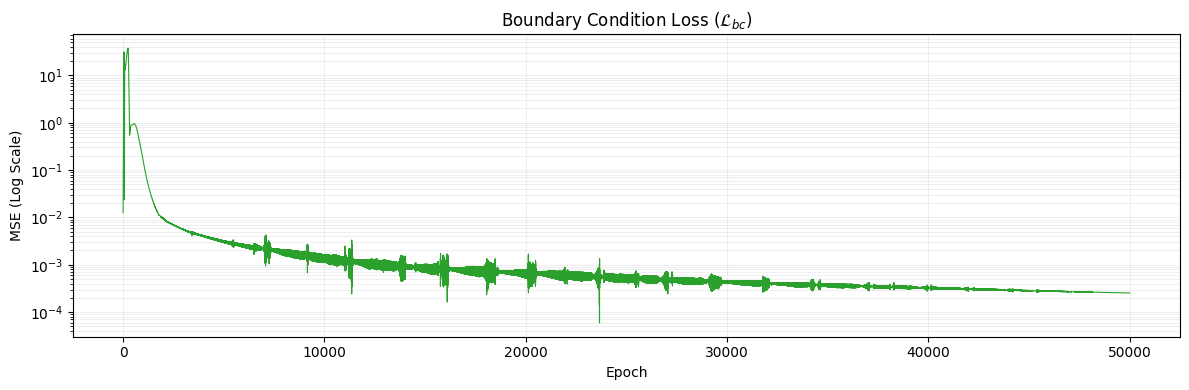

In [56]:
# Setting up the figure
plt.figure(figsize=(12, 4))
plt.plot(history['epoch'], history['bc'], color='tab:green', lw=0.8)
plt.yscale('log')

# Title, axes titles, and grid
plt.title('Boundary Condition Loss ($\mathcal{L}_{bc}$)')
plt.xlabel('Epoch')
plt.ylabel('MSE (Log Scale)')
plt.grid(True, which="both", ls="-", alpha=0.2)

# Tight layout
plt.tight_layout()

# # Saving and showing the figure
plt.savefig(out_path_loss_bc, bbox_inches="tight")
plt.show()

### Greeks

In [57]:
# Running the greeks notebook
%run greeks.ipynb

In [58]:
# Setting up a test point: At-the-Money (S=K) at 6 months (tau=0.5)
S_test = torch.tensor([[K]], device=device, requires_grad=True)
tau_test = torch.tensor([[0.5]], device=device, requires_grad=True)

# Compute all Greeks
greeks = compute_greeks(model, S_test, tau_test)

# Analytical truth for comparison
V_true = bs(K, K, 0.5, r, sigma)

### Printout

In [59]:
def fmt(val):
    return f"{val.item():12.6f}" if val is not None else "         N/A"

g = greeks

rows = [
    ("Price (V)",  "V(S,τ)",     "-",  fmt(g["V"])),
    ("Delta (Δ)",  "∂V/∂S",     "1st", fmt(g["Delta"])),
    ("Theta (Θ)",  "∂V/∂τ",     "1st", fmt(g["Theta"])),
    ("Rho (ρ)",    "∂V/∂r",     "1st", fmt(g["Rho"])),
    ("Phi (Φ)",    "∂V/∂q",     "1st", fmt(g["Phi"])),
    ("Vega",       "∂V/∂σ",     "1st", fmt(g["Vega"])),
    ("Gamma (Γ)",  "∂²V/∂S²",   "2nd", fmt(g["Gamma"])),
    ("Vomma",      "∂²V/∂σ²",   "2nd", fmt(g["Vomma"])),
    ("Vanna",      "∂²V/∂S∂σ",  "2nd", fmt(g["Vanna"])),
    ("Charm",      "∂²V/∂S∂τ",  "2nd", fmt(g["Charm"])),
    ("Speed",      "∂³V/∂S³",   "3rd", fmt(g["Speed"])),
    ("Zomma",      "∂³V/∂S²∂σ", "3rd", fmt(g["Zomma"])),
    ("Color",      "∂³V/∂S²∂τ", "3rd", fmt(g["Color"])),
]

print("\n" + "=" * 65)
print(f"{'GREEK':<12} | {'EXPRESSION':<16} | {'ORDER':<5} | {'PINN VALUE':>12}")
print("-" * 65)

for name, expr, order, val in rows:
    print(f"{name:<12} | {expr:<16} | {order:<5} | {val}")
print("-" * 65)

res = g["Theta"] - (0.5 * sigma**2 * S_test**2 * g["Gamma"] + r * S_test * g["Delta"] - r * g["V"])

print(f"{'PDE Residual':<12} | {'(Goal: 0.0)':<16} | {'':<5} | {res.item():12.6e}")
print("=" * 65)
print(f"\nAnalytical Price: {V_true:.6f}")


GREEK        | EXPRESSION       | ORDER |   PINN VALUE
-----------------------------------------------------------------
Price (V)    | V(S,τ)           | -     |     6.927159
Delta (Δ)    | ∂V/∂S            | 1st   |     0.597287
Theta (Θ)    | ∂V/∂τ            | 1st   |     8.053441
Rho (ρ)      | ∂V/∂r            | 1st   |          N/A
Phi (Φ)      | ∂V/∂q            | 1st   |          N/A
Vega         | ∂V/∂σ            | 1st   |          N/A
Gamma (Γ)    | ∂²V/∂S²          | 2nd   |     0.027053
Vomma        | ∂²V/∂σ²          | 2nd   |          N/A
Vanna        | ∂²V/∂S∂σ         | 2nd   |          N/A
Charm        | ∂²V/∂S∂τ         | 2nd   |     0.093996
Speed        | ∂³V/∂S³          | 3rd   |    -0.000629
Zomma        | ∂³V/∂S²∂σ        | 3rd   |          N/A
Color        | ∂³V/∂S²∂τ        | 3rd   |    -0.027441
-----------------------------------------------------------------
PDE Residual | (Goal: 0.0)      |       | 2.746582e-03

Analytical Price: 6.888729


### Download Plots (Colab)

In [60]:
if IN_COLAB:
    print(f"Plots already saved to Google Drive: {out_dir}")
else:
    print(f"PDFs saved locally to: {out_dir.resolve()}")

Plots already saved to Google Drive: /content/drive/MyDrive/GITHUB-COLAB/fys5429/code/plots/eda
